# **Colabユーザーへの注意**

# **このファイルに直接書き込まないでください—作業が消えることがあります！**

# **必ず作業前にコピーを作成してください。**

コピーの作り方

1. 左上の「File」をクリック  
> *「File」や「Runtime」などのメニューが見えないときは、右上の“v”マークを押して表示してください。*

2. 「Save a copy in Drive」を選ぶ  

3. コピーしたファイル名を「YOURNAMEs_FileName.ipynb」に変更する  
> 例：名前がOliviaなら → Olivias_FileName.ipynb  


---

* チェックマーク（✅）は保存されません。Chromeのリロードボタンでページを更新すると消えます。<br>  
途中で止めるときは、テキストセルを追加して「SO FAR DONE」など書いておいてください。

---

* Colabでは**30分〜90分ごとに以前の出力結果がリセットされます**。<br>  
そのため、`~~ is not defined`のようなエラーが**すごくよく起こります**。

🔁 `~~ is not defined`エラーが出たらどうする？

1. まず変数名のスペルを確認してください。<br>  
2. スペルが正しいのにまだエラーが出るなら、**そのセルをクリックして選択**してください。<br>  
3. 左上の「Runtime」→「Run before」をクリック。<br>  
→ これで**それまでのすべてのセルが再実行されます**。  
4. 再度、そのセルを実行してください。

もしこれでもエラーが直らなければ、<br>  
前のセルのTODOの答えに基本的なミスがあるかもしれません。<br>  
正しいかどうか確認してください。<br>  
またはChatGPTや他のコーディングアシスタントに助けを求めましょう。

In [ ]:
# A Function to Display Tensors Nicely (Feel Free to Skip This)
import torch
import torch.nn as nn
import torch.nn.functional as F

def print_formatted_tensor(*args, width=6, decimals=2):
    """
    A function that neatly formats and displays a PyTorch Tensor, and also prints its size.

    Example usage:
        print_formatted_tensor("name", tensor)
        print_formatted_tensor(tensor)

    Args:
        *args: If given 1 argument, it is treated as a tensor.
               If given 2 arguments, the first is treated as the name, the second as the tensor.
        width (int): Display width for each number (default: 6)
        decimals (int): Number of decimal places to show (default: 2)
    """

    # Determine tensor and name from arguments
    if not args:
        raise ValueError("At least one argument is required.")
    if isinstance(args[0], str):
        if len(args) < 2:
            raise ValueError("Tensor is not specified.")
        name, tensor = args[0], args[1]
    else:
        name, tensor = None, args[0]

    # Convert Tensor to List
    tensor_list = tensor.detach().cpu().tolist()

    def format_list(lst, indent):
        """Formatting a recursively nested list and returning a string"""
        # If the contents are lists, then re-return
        if isinstance(lst, list) and lst and isinstance(lst[0], list):
            inner = ",\n".join(" " * indent + format_list(sub, indent + 2) for sub in lst)
            return "[\n" + inner + "\n" + " " * (indent - 2) + "]"
        # For numerical lists
        return "[" + ", ".join(f"{v:{width}.{decimals}f}" for v in lst) + "]"

    # Formatted string (bar brackets on outermost frames are removed)
    formatted = format_list(tensor_list, indent=9)
    inner_formatted = formatted[1:-1].strip()

    # Result output
    if name:
        print(name)
    print(f"Tensor Size: {list(tensor.size())}")
    print("tensor([")
    print(" " * 9 + inner_formatted)
    print(" " * 7 + "])")

# **Chapter 19: Long Train**

### **Section 1: npyファイルへの変換**

前回は1時間しか訓練できず、検証誤差や訓練誤差が下げ止まる前に訓練を停止してしまいました。

今回はおよそ6時間かけて、モデルをしっかり学習させます。

その上で、システムRAMを圧迫しないように、データのサンプリング方法をインデックスアクセス方式に変更します。

長時間の訓練でモデルはよりChatGPTへの近づいていきます。

それでは、始めましょう。

In [ ]:
data_file = "https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu/resolve/main/sample/10BT/000_00000.parquet"

```python
関数: load_dataset
引数:
path: "parquet",
data_files: THINK_BY_YOURSELF
split : "train"
cache_dir : "/content/fineweb.txt"
```

* `load_dataset` は 🤗 Hugging Face Datasets ライブラリの関数で、指定した形式のデータセットを読み込む。
* `path="parquet"` は、読み込むファイルが **Parquet形式** であることを示す。
* `data_files=data_file` は読み込む対象ファイル（ファイルパスまたはリスト）を指定。
* `split="train"` は **分割**（例: train, testなど）を指定。
* `cache_dir="/content/fineweb"` により、ダウンロードされたデータセットがキャッシュされるディレクトリを指定。

In [ ]:
from datasets import load_dataset
ds = load_dataset(path="parquet", data_files=data_file, split="train", cache_dir="/content/fineweb") # TODO: 関数(引数)

`ds`は HuggingFace Datasets ライブラリ独自の `Dataset` クラスのインスタンスになっています。

In [ ]:
ds

Dataset({
    features: ['text', 'id', 'dump', 'url', 'file_path', 'language', 'language_score', 'token_count', 'score', 'int_score'],
    num_rows: 726000
})

In [ ]:
# 文書境界
boundary = "<|endoftext|>"

with open("fineweb.txt", "w", encoding="utf-8") as f:
    for sample in ds:
        f.write(boundary + sample["text"])

#### ⚡ T4 GPUでの効率的な学習データ準備

今回は T4 GPU を使い、約 6時間 の学習を行います。  
十分なデータ量を確保するため、約 3.3GB のテキストファイル（fineweb.txt）を使用します。

---

🚨 課題：RAMの逼迫

これまでは、テキスト全体を一度にメモリへ読み込み、  
そこからランダムにサンプリングしていました。  

しかし、この方法ではファイルサイズが3GBを超えると  
システムRAM（約12〜16GB）を使い切ってしまい、セッションがクラッシュしてしまいます。

---

💡 解決策：NumPyのメモリマップ＋インデックスアクセス

RAMを圧迫しないよう、NumPyのメモリマップ機能（`mmap_mode="r"`）を使います。  
これにより、ファイル全体を展開せずに、必要な部分だけをインデックス指定で読み出すことができます。
  
なお、「インデックスアクセス」とは、巨大なファイルの中から特定の位置（インデックス）だけを読み込む方法です。   

これにより、RAMの使用量を最小限に抑えながら、高速で読み込めます。

---

⚙️ 一連の処理フロー

1. テキストを `tiktoken` で事前に トークンID列（整数列） に変換  
2. トークン列を `int32` 形式で バイナリファイル（.bin） として保存  
3. `.bin` を NumPy形式（.npy） に変換  
4. `np.load(..., mmap_mode="r")` で メモリマップ読み込み

この仕組みによって、ファイル全体をRAMに載せずに、必要な部分のみを読み出すことが可能 になります。



1. テキストを `tiktoken` で事前に トークンID列（整数列） に変換  

In [ ]:
import numpy as np
import tiktoken
import os

In [ ]:
# ファイルパス指定
input_text_path = "fineweb.txt"

```python
関数: tiktoken.get_encoding
引数: エンコーディング名（例: "gpt2"）
```

* `tiktoken.get_encoding("gpt2")` は、OpenAI の `tiktoken` ライブラリから **GPT-2用のトークナイザ（エンコーダ）** を取得。
* GPT系モデルに対応したトークン変換を行うために使用される。
* 取得されたエンコーダは、テキストをトークンID列に変換したり、逆変換する機能を持つ。

In [ ]:
# トークナイザーを準備
encoder = tiktoken.get_encoding("gpt2") # TODO: 関数(引数)

ファイルには億単位の文字があります。この文字をencodeしてトークン列にします。

```python
関数: open
引数: file = テキストファイルのパス。THINK_BY_YOURSELF, mode = "r", encoding="utf-8"
```

* 指定されたパスのテキストファイルを **読み込みモード ("r")** で開く。
* `encoding="utf-8"` により文字コードを UTF-8 に指定。
* 戻り値はファイルオブジェクトで、読み取り・書き込みなどが可能。

In [ ]:
text_file = open(file=input_text_path, mode="r", encoding="utf-8") # TODO: 関数(引数)

`fineweb.txt`には何億文字もあります。一度に全てをencodeしようとすると、システムRAMがクラッシュしてしまいます。

そこで、少しずつ一定の長さの文字列を切り出します。この塊をチャンクと言います。

このチャンクをencodeします。これにより巨大なファイルを少しずつ処理していきます。



```python
インスタンス: text_file
メソッド: THINK_BY_YOURSELF
引数: 100（読み込む文字数）
```

* ファイルオブジェクト `text_file` から100文字だけを読み込みます。
* 読み込まれた文字列は `chunk` 変数に格納されます。


In [ ]:
chunk = text_file.read(100)  # TODO: インスタンス.メソッド（引数）
print(chunk)

<|endoftext|>The Independent Jane
For all the love, romance and scandal in Jane Austen’s books, what


```python
インスタンス: text_file
メソッド: close
引数: なし
```

* `text_file.close()` は、開いていたファイルを閉じるためのメソッドです。
* ファイル操作後にリソースを解放するため、忘れずに `close()` を呼び出すことが重要です。
* 特に `open()` を使ってファイルを開いた場合は、`close()` を明示的に行う必要があります。

In [ ]:
text_file.close() # TODO: インスタンス.メソッド（引数）

```python
インスタンス: encoder
メソッド: THINK_BY_YOURSELF
引数: chunk（変換対象の文字列）, allowed_special="all"
```

* テキスト `chunk` をトークンIDのリストに変換します。
* `allowed_special="all"` により、すべての特殊トークンを許可します（たとえば `<|endoftext|>` などもトークンとして扱える）。
* 出力は整数のリストである `tokens` に代入され、モデルへの入力準備が整います。

In [ ]:
# トークン化
tokens = encoder.encode(chunk, allowed_special="all") # TODO: インスタンス.メソッド(文字列, allowed_special="all") を適用
print("tokens:", tokens)

tokens: [50256, 464, 13362, 12091, 198, 1890, 477, 262, 1842, 11, 19661, 290, 10731, 287, 12091, 2517, 268, 447, 247, 82, 3835, 11, 644]


```python
関数: np.array
引数: tokens（リスト）, dtype=np.int32（データ型指定）
```

* `np.array(tokens, dtype=np.int32)` は、リスト `tokens` を NumPy 配列に変換します。
* `dtype=np.int32` により、配列内の要素が 32ビット整数型であることを明示します。
* 変換後の配列 `arr` は、数値処理や機械学習モデルの入力として扱いやすくなります。


In [ ]:
# NumPy配列に変換する
arr = np.array(tokens, dtype=np.int32) # TODO: 関数(リスト, dtype=指定) を適用
print("numpy array\n", arr)

numpy array
 [50256   464 13362 12091   198  1890   477   262  1842    11 19661   290
 10731   287 12091  2517   268   447   247    82  3835    11   644]


2. トークン列を `int32` 形式で バイナリファイル（.bin） として保存

In [ ]:
sample_bin_path = "sample.bin"

```python
関数: open
引数: file=THINK_BY_YOURSELF, mode="wb"（バイナリ書き込みモード）
```

* `with open(file=..., mode="wb") as f:` は、`file=...`に対応するファイルを**バイナリ書き込みモード** (`"wb"`) で開きます。
* `"wb"` で開くと、ファイルが存在する場合は中身が削除され、空の状態から書き込めるようになります。
* `with` 文を使えば自動でクローズされるため、`f.close()` は不要です。

In [ ]:
# 出力ファイルを空にしておく（既存データ削除）
with open(file=sample_bin_path, mode="wb") as f: # TODO: with open(file=...., mode=...) as f:
    pass

```python
関数: open  
引数: file=THINK_BY_YOURSELF, mode="ab"（バイナリ追記モード）
```

* `open(file=..., mode="ab")` は、バイナリファイルを **追記モード（append binary）** で開きます。
* `"ab"` モードでは、すでに存在するファイルの末尾にデータを追加できます（既存内容は保持される）。
* 返されたバイナリファイルオブジェクトは `sample_bin_file` に格納され、以降の書き込み処理に使用されます。

In [ ]:
sample_bin_file = open(file=sample_bin_path, mode="ab") # TODO: 関数(引数)

```python
インスタンス: arr（NumPy配列）  
メソッド: tofile  
引数: バイナリファイルオブジェクト、THINK_BY_YOURSELF
```

* NumPy配列 `arr` をバイナリ形式でファイルに書き込みます。
* 引数には、書き込み先のファイルオブジェクト `sample_bin_file` を指定します。
* 書き込まれるのは配列の生データで、テキスト形式ではない点に注意が必要です。


In [ ]:
# NumPy配列をバイナリファイルに書き込む
arr.tofile(sample_bin_file) # TODO: インスタンス.メソッド（引数）

実は上記の`tofile`では、ディスクにあるファイルにデータを書き込めているわけではありません。

ファイルにデータを書き込むとき、Python は すぐにディスクに書き込むわけではありません。

一度「バッファ（メモリ上の一時領域）」にデータを書き込んでいき、
ある程度たまったタイミングでまとめてディスクに書き出します。

しかし、大量のチャンクを処理している場合、バッファにある古いチャンクのデータが新しいチャンクのデータで上書きされてしまうことがあります。

そのため、チャンクごとに確実にディスクに反映します。

バッファは「まだディスクに書かれていないデータの一時保管場所」で、
`flush` は、このバッファに溜まっているデータを強制的にディスクに書き出すメソッドです。

```python
インスタンス: バイナリファイルオブジェクト（THINK_BY_YOURSELF）
メソッド: flush  
引数: なし
```

* `flush()` は、バッファに保持されている書き込み内容を**即座にディスクに反映**します。
* 通常は `close()` で自動的に書き込まれますが、大量のデータを分割して書き込む場合などに、明示的に `flush()` を使って中間状態を保存できます。


In [ ]:
sample_bin_file.flush() # TODO: インスタンス.メソッド（引数）

`sample_bin_file`をクローズしてください。

In [ ]:
sample_bin_file.close() # TODO: THINK_BY_YOURSELF

```python
関数: np.fromfile  
引数: file=THINK_BY_YOURSELF, dtype=THINK_BY_YOURSELF
```

* `np.fromfile` は、バイナリファイルからデータを読み取り、指定されたデータ型の NumPy 配列として復元します。
* 書き込み時と同じ `dtype` を使うことで、正しい形でデータを読み戻すことができます。
* 読み込まれた配列は `arr` に格納され、処理や検証に使用されます。

In [ ]:
# バイナリファイルから読み戻し
arr = np.fromfile(file=sample_bin_path, dtype=np.int32) # TODO: 関数(引数)
print("numpy array\n", arr)

numpy array
 []


ここまでは、100文字の1つのチャンクの処理を見てきました。

ここからは、億単位の文字がある`fineweb.txt`を、1,000万文字のチャンクでencodeしていきます。

🔘 **Options**: 余計な選択肢があるかもしれません。同じ選択肢を2回以上使うかもしれません。

`tiktoken`　`openai`　`get_encoding`　`"gpt2"`　`encoder`　`decoder`　`encode`　`decode`,　`output_bin_path`　`input_text_path`　`"w"`　`"r"`　`"ab"`　`"wb"`　`"utf-8"`　`chunk_size`　`chunk`　`np.array`　`tokens`　`np.int32`　`np.int8`　`tofile`　`arr`　`flush()`　`finish()`　`total_tokens`

In [ ]:
"""
input_text_path = "/content/fineweb.txt"
output_bin_path = "/content/fineweb.bin"
chunk_size = 10_000_000
encoder = ________.___________(____) # TODO: FILL
# 出力バイナリファイルを空にしておく（既存データ削除）
with open(file=______________, mode=__) as f: # TODO: FILL
    pass
# 全トークン数をカウントする変数
total_tokens = 0
# テキストファイルを開き、トークン化 → バイナリ保存
with open(file=___________, mode=__, encoding=_____) as text_file:  # TODO: FILL
    with open(file=____________, mode=___) as bin_file: # TODO: FILL
        while True:
            # 一定サイズずつテキストを読み込む
            chunk = text_file.read(________) # TODO: FILL

            # 読み込みが終わったらループを抜ける
            if not chunk:
                break

            # テキストをトークンに変換
            tokens = ________._______(_____, allowed_special="all") # TODO: FILL

            # NumPy配列に変換（型をint32に）
            arr = ________(_____, dtype=______) # TODO: FILL

            # バイナリファイルに書き込む
            ___._____(bin_file) # TODO: FILL

            # ファイルへの書き込みを確実に反映
            bin_file.______ # TODO: FILL

            # 処理済みトークン数を更新
            ___________ += len(arr) # TODO: FILL

            # 進行状況を表示
            print(f"✅ {total_tokens:,} tokens processed...")

# 最終結果を表示
print(f"\n🎉 完了！ 合計 {total_tokens:,} トークンを保存しました。")
"""

'\ninput_text_path = "/content/fineweb.txt"\noutput_bin_path = "/content/fineweb.bin"\nchunk_size = 10_000_000\nencoder = ________.___________(____) # TODO: FILL\n# 出力バイナリファイルを空にしておく（既存データ削除）\nwith open(file=______________, mode=__) as f: # TODO: FILL\n    pass\n# 全トークン数をカウントする変数\ntotal_tokens = 0\n# テキストファイルを開き、トークン化 → バイナリ保存\nwith open(file=___________, mode=__, encoding=_____) as text_file:  # TODO: FILL\n    with open(file=____________, mode=___) as bin_file: # TODO: FILL\n        while True:\n            # 一定サイズずつテキストを読み込む\n            chunk = text_file.read(________) # TODO: FILL\n            \n            # 読み込みが終わったらループを抜ける\n            if not chunk:\n                break\n\n            # テキストをトークンに変換\n            tokens = ________._______(_____, allowed_special="all") # TODO: FILL\n            \n            # NumPy配列に変換（型をint32に）\n            arr = ________(_____, dtype=______) # TODO: FILL\n            \n            # バイナリファイルに書き込む\n            ___._____(bin_file) # TODO: FI

In [ ]:
input_text_path = "/content/fineweb.txt"
output_bin_path = "/content/fineweb.bin"
chunk_size = 10_000_000
encoder = tiktoken.get_encoding("gpt2")

# 全トークン数をカウントする変数
total_tokens = 0

# テキストファイルを開き、トークン化 → バイナリ保存
with open(input_text_path, "r", encoding="utf-8") as f:
    with open(output_bin_path, "ab") as out:
        while True:
            # 一定サイズずつテキストを読み込む
            chunk = f.read(chunk_size)

            # 読み込みが終わったらループを抜ける
            if not chunk:
                break

            # テキストをトークンに変換
            tokens = encoder.encode(chunk, allowed_special="all")

            # NumPy配列に変換（型をint32に）
            arr = np.array(tokens, dtype=np.int32)

            # バイナリファイルに書き込む
            arr.tofile(out)

            # ファイルへの書き込みを確実に反映
            out.flush()

            # 処理済みトークン数を更新
            total_tokens += len(arr)

            # 進行状況を表示
            print(f"✅ {total_tokens:,} tokens processed...")

# 最終結果を表示
print(f"\n🎉 完了！ 合計 {total_tokens:,} トークンを保存しました。")

✅ 2,165,931 tokens processed...
✅ 4,346,808 tokens processed...
✅ 6,526,193 tokens processed...
✅ 8,696,829 tokens processed...
✅ 10,867,888 tokens processed...
✅ 13,033,721 tokens processed...
✅ 15,188,617 tokens processed...
✅ 17,353,056 tokens processed...
✅ 19,514,546 tokens processed...
✅ 21,698,507 tokens processed...
✅ 23,878,952 tokens processed...
✅ 26,053,798 tokens processed...
✅ 28,232,615 tokens processed...
✅ 30,404,934 tokens processed...
✅ 32,585,456 tokens processed...
✅ 34,751,478 tokens processed...
✅ 36,914,780 tokens processed...
✅ 39,103,383 tokens processed...
✅ 41,261,826 tokens processed...
✅ 43,419,252 tokens processed...
✅ 45,574,328 tokens processed...
✅ 47,741,394 tokens processed...
✅ 49,898,243 tokens processed...
✅ 52,091,902 tokens processed...
✅ 54,279,292 tokens processed...
✅ 56,456,755 tokens processed...
✅ 58,642,979 tokens processed...
✅ 60,829,516 tokens processed...
✅ 62,998,852 tokens processed...
✅ 65,166,772 tokens processed...
✅ 67,343,405 t

<details>
<summary>クリックして答えを表示/非表示</summary>

```python
input_text_path = "/content/fineweb.txt"
output_bin_path = "/content/fineweb.bin"
chunk_size = 10_000_000
encoder = tiktoken.get_encoding("gpt2")

# 全トークン数をカウントする変数
total_tokens = 0

# テキストファイルを開き、トークン化 → バイナリ保存
with open(input_text_path, "r", encoding="utf-8") as f:
    with open(output_bin_path, "ab") as out:
        while True:
            # 一定サイズずつテキストを読み込む
            chunk = f.read(chunk_size)
            
            # 読み込みが終わったらループを抜ける
            if not chunk:
                break

            # テキストをトークンに変換
            tokens = encoder.encode(chunk, allowed_special="all")
            
            # NumPy配列に変換（型をint32に）
            arr = np.array(tokens, dtype=np.int32)
            
            # バイナリファイルに書き込む
            arr.tofile(out)
            
            # ファイルへの書き込みを確実に反映
            out.flush()

            # 処理済みトークン数を更新
            total_tokens += len(arr)
            
            # 進行状況を表示
            print(f"✅ {total_tokens:,} tokens processed...")

# 最終結果を表示
print(f"\n🎉 完了！ 合計 {total_tokens:,} トークンを保存しました。")
```

3. `.bin` を NumPy形式（.npy） に変換  

バイナリファイルのままでもインデックスアクセスはできますが、numpyファイルの方が一般的なので、numpyファイルに変更します。

優位点：numpyファイルは`int32`のような型情報をファイル内部に含むため、他人が受け取った時にわかりやすい。

バイナリファイルでは、これは`int32`だという情報がファイル内に含まれないので、READMEまたはファイル名に記載するなどの方法が取られます。

```python
関数: np.fromfile
引数: file=バイナリファイルのパス, dtype=データ型（ここではnp.int32）
```

* `np.fromfile()` は、バイナリファイルから直接 NumPy 配列を生成する関数です。
* `dtype=np.int32`：バイナリデータを `int32`（4バイト整数）として読み取ります。
* 数値の生データ（例：トークンIDなど）を高速に読み込む用途で使われます。

In [ ]:
# 1️⃣ 生バイナリを int32 として読み込む。
# テキストデータではなく数値データなのでシステムRAMへの負担は3GB程度。
data = np.fromfile(file=output_bin_path, dtype=np.int32) # TODO: np.fromfile(file=ファイルパス, dtype=データ型) を適用
print("読み込んだトークン数:", len(data))

読み込んだトークン数: 767286496


```python
関数: np.save
引数: file=保存先のパス, arr=保存するNumPy配列
```

* `np.save()` は、NumPy配列を `.npy` 形式で保存する関数です。
* `.npy` 形式は、NumPy配列を効率的に格納・読み出しできる公式フォーマットです。
* `file=npy_path`: 保存先ファイルのパス。

In [ ]:
# 2️⃣ 正しい .npy フォーマットで保存
npy_path = "/content/fineweb.npy"
np.save(file=npy_path, arr=data) # TODO: 関数(引数)

4. `np.load(..., mmap_mode="r")` で メモリマップ読み込み

```python
関数: np.load
引数: file=読み込む .npy ファイルのパス, mmap_mode="r"
```

* `np.load()` は `.npy` 形式で保存された NumPy 配列を読み込む関数です。
* `mmap_mode="r"` を指定することで、**メモリマップ**（memory-mapping）が有効になります。

  * これにより、ファイル全体を一度に読み込まず、必要な部分だけを読み込むことができ、RAMの節約になります。
* `tokens = np.load(...)` により、`.npy` ファイルからトークン列（配列）を効率的に読み出します。

In [ ]:
tokens = np.load(file=npy_path, mmap_mode="r") # TODO: np.load(file=ファイルパス, mmap_mode="r") を適用
sample_tokens = tokens[100:200]
print(sample_tokens)

[35287   286 11182 22578   290  6970   607  2988   561 48866   373  8468
   772   329  2517   268    13   554   607   938  1492 15397 30451   318
 25562   284 11148  8599 29866  9268   379 11182  9223   741   447   247
    82 30696    13   198  7003 12091  2826   416   262  3173   286   262
  1110    11   477   286   607  3597   318 37681   351   703   673  2227
  1204   284   307    13  1375   564   246  1416  1476    82   447   247
   607 11616   379   262 11247   329  1466   287 18966    13   198  2215
   697   455   276   416  9074    13  2574  1122    11 12091 33514  1139
    11   198   447   250]


今はnumpy配列ですが、モデルに入力する際はtorch.tensor形式にする必要があります。

```python
関数: torch.from_numpy
引数: NumPy配列 (sample_tokens)
```

* `torch.from_numpy(sample_tokens)` は NumPy 配列を **PyTorch テンソル** に変換します。
* 出力は、NumPy配列と同じ形状・型を持つ `torch.Tensor` になります。


In [ ]:
torch_sample_tokens = torch.from_numpy(sample_tokens) # TODO: torch.from_numpy(NumPy配列)
print(torch_sample_tokens)

tensor([35287,   286, 11182, 22578,   290,  6970,   607,  2988,   561, 48866,
          373,  8468,   772,   329,  2517,   268,    13,   554,   607,   938,
         1492, 15397, 30451,   318, 25562,   284, 11148,  8599, 29866,  9268,
          379, 11182,  9223,   741,   447,   247,    82, 30696,    13,   198,
         7003, 12091,  2826,   416,   262,  3173,   286,   262,  1110,    11,
          477,   286,   607,  3597,   318, 37681,   351,   703,   673,  2227,
         1204,   284,   307,    13,  1375,   564,   246,  1416,  1476,    82,
          447,   247,   607, 11616,   379,   262, 11247,   329,  1466,   287,
        18966,    13,   198,  2215,   697,   455,   276,   416,  9074,    13,
         2574,  1122,    11, 12091, 33514,  1139,    11,   198,   447,   250],
       dtype=torch.int32)


torch.tensorの形式になりました。dtypeがtorch.int32であることがわかると思います。

※「not writable」との警告が出てるかもしれません。読み込みモードで開いているので書き込みができないのは正常な反応であり、問題ありません。

Pytorchの`nn.Embedding`は torch.int64 しか受け付けません。

そのため、np.int32からnp.int64に変換します。その上で、`torch.from_numpy` を適用します。

これにより、torch.int64 に変換されます。

```python
元の変数：sample_tokens (np.int32)
メソッド: astype
引数: データ型（np.int64）

新しい変数 = 元の変数.メソッド（引数）
```

* `sample_tokens.astype(np.int64)` は、NumPy 配列 `sample_tokens` のデータ型を `int32`から`int64`（64ビット整数）に変換します。
* 元の配列は変更されず、新たな `int64` 型の配列が生成されます。
* PyTorch では `torch.from_numpy()` でテンソルに変換する前に、NumPy 配列を明示的に整数型へ変換するのが一般的です。

In [ ]:
sample_tokens_int64 = sample_tokens.astype(np.int64) # TODO: 元の変数.メソッド（引数）
torch_sample_tokens = torch.from_numpy(sample_tokens_int64)
print(torch_sample_tokens)

tensor([35287,   286, 11182, 22578,   290,  6970,   607,  2988,   561, 48866,
          373,  8468,   772,   329,  2517,   268,    13,   554,   607,   938,
         1492, 15397, 30451,   318, 25562,   284, 11148,  8599, 29866,  9268,
          379, 11182,  9223,   741,   447,   247,    82, 30696,    13,   198,
         7003, 12091,  2826,   416,   262,  3173,   286,   262,  1110,    11,
          477,   286,   607,  3597,   318, 37681,   351,   703,   673,  2227,
         1204,   284,   307,    13,  1375,   564,   246,  1416,  1476,    82,
          447,   247,   607, 11616,   379,   262, 11247,   329,  1466,   287,
        18966,    13,   198,  2215,   697,   455,   276,   416,  9074,    13,
         2574,  1122,    11, 12091, 33514,  1139,    11,   198,   447,   250])


**Section 1: npyファイルへの変換**<label><input type="checkbox"> Mark as Done</label>

### **Section 2: Dataloaderクラスの改良**

🔘 **Options**: 余計な選択肢があるかもしれません。同じ選択肢を2回以上使うかもしれません。

`np`　`torch`　`load`　`open`　`"r"`　`npy_path`　`0`　`split_index`　`np.random`　`randint`　`np.int64`　`np.int32`　`np.float32`


In [ ]:
"""
import torch
########## NEW ##########
import numpy as __ # TODO: FILL
########## NEW ##########

class DataLoader:
    def __init__(self, npy_path, config):
        # 大きなトークン化済みファイル（.npy）をメモリマップで開き、
        # 必要な部分だけをランダムに読み出すデータローダー。
        self.config = config  # モデル設定（batch_size, seq_lenなど）

        self.encoder = tiktoken.get_encoding("gpt2")
        self.vocab_size = self.encoder.n_vocab

        ########## NEW ##########
        # 巨大なトークン化済み .npy ファイルをメモリマップで開く
        self.data = ____.____(______, mmap_mode="r")  # TODO: FILL
        ########## NEW ##########

        # 訓練・検証用データの範囲を決める（実データは共有）
        self.train_data, self.val_data = self.split_data()

    def split_data(self):
        # データを 90%:10% に分割し、インデックス範囲で保持
        split_index = int(0.9 * len(self.data))
        ########## NEW ##########
        return (__, _________), (_________, len(self.data))  # TODO: FILL
        ########## NEW ##########

    def get_batch(self, split):

        # 指定された split ('train' or 'val') からランダムにバッチを作る。
        # メモリに乗らない巨大ファイルから、必要部分だけをスライスして読み込む。

        ########## NEW ##########
        # splitに応じたデータ範囲を取得
        range_start, range_end = (
            self.train_data if split == 'train' else self.val_data
        )

        # ランダムに開始位置を選ぶ
        start_indices = _________._______(
            range_start,
            range_end - self.config.input_sequence_length - 1,
            size=self.config.batch_size
        )

        # 各開始位置から連続したトークン列を取り出してバッチ化
        input_sequences = torch.stack([
            torch.from_numpy(
                self.data[start:start + self.config.input_sequence_length].astype(________)
            )
            for start in start_indices
        ])

        # 1トークン先をターゲットにする
        target_sequences = torch.stack([
            torch.from_numpy(
                self.data[start + 1:start + self.config.input_sequence_length + 1].astype(________)
            )
            for start in start_indices
        ])
        ########## NEW ##########

        # GPUなどのデバイスに転送
        return (
            input_sequences.to(self.config.device_type),
            target_sequences.to(self.config.device_type)
        )
"""

In [ ]:
import torch
########## NEW ##########
import numpy as np
########## NEW ##########

class DataLoader:
    def __init__(self, npy_path, config):
        # 大きなトークン化済みファイル（.npy）をメモリマップで開き、
        # 必要な部分だけをランダムに読み出すデータローダー。
        self.config = config  # モデル設定（batch_size, seq_lenなど）

        self.encoder = tiktoken.get_encoding("gpt2")
        self.vocab_size = self.encoder.n_vocab

        ########## NEW ##########
        # 巨大なトークン化済み .npy ファイルをメモリマップで開く
        self.data = np.load(npy_path, mmap_mode="r")
        ########## NEW ##########

        # 訓練・検証用データの範囲を決める（実データは共有）
        self.train_data, self.val_data = self.split_data()

    def split_data(self):
        # データを 90%:10% に分割し、インデックス範囲で保持
        split_index = int(0.9 * len(self.data))
        ########## NEW ##########
        return (0, split_index), (split_index, len(self.data))
        ########## NEW ##########

    def get_batch(self, split):

        # 指定された split ('train' or 'val') からランダムにバッチを作る。
        # メモリに乗らない巨大ファイルから、必要部分だけをスライスして読み込む。

        ########## NEW ##########
        # splitに応じたデータ範囲を取得
        range_start, range_end = (
            self.train_data if split == 'train' else self.val_data
        )

        # ランダムに開始位置を選ぶ
        start_indices = np.random.randint(
            range_start,
            range_end - self.config.input_sequence_length - 1,
            size=self.config.batch_size
        )

        # 各開始位置から連続したトークン列を取り出してバッチ化
        # Pytorchの`nn.Embedding`は torch.int64 しか受け付けない。
        # np.int64に変換した状態で torch.from_numpy を適用すると、torch.int64 に変換される。
        input_sequences = torch.stack([
            torch.from_numpy(
                self.data[start:start + self.config.input_sequence_length].astype(np.int64)
            )
            for start in start_indices
        ])

        # 1トークン先をターゲットにする
        # Pytorchの`nn.Embedding`はtorch.int64しか受け付けないため、np.int64に変換する必要がある。
        target_sequences = torch.stack([
            torch.from_numpy(
                self.data[start + 1:start + self.config.input_sequence_length + 1].astype(np.int64)
            )
            for start in start_indices
        ])
        ########## NEW ##########

        # GPUなどのデバイスに転送
        return (
            input_sequences.to(self.config.device_type),
            target_sequences.to(self.config.device_type)
        )

<details>
<summary>クリックして答えを表示/非表示</summary>

```python
import torch
########## NEW ##########
import numpy as np
########## NEW ##########

class DataLoader:
    def __init__(self, npy_path, config):
        # 大きなトークン化済みファイル（.npy）をメモリマップで開き、
        # 必要な部分だけをランダムに読み出すデータローダー。
        self.config = config  # モデル設定（batch_size, seq_lenなど）

        self.encoder = tiktoken.get_encoding("gpt2")
        self.vocab_size = self.encoder.n_vocab

        ########## NEW ##########
        # 巨大なトークン化済み .npy ファイルをメモリマップで開く
        self.data = np.load(npy_path, mmap_mode="r")
        ########## NEW ##########

        # 訓練・検証用データの範囲を決める（実データは共有）
        self.train_data, self.val_data = self.split_data()

    def split_data(self):
        # データを 90%:10% に分割し、インデックス範囲で保持
        split_index = int(0.9 * len(self.data))
        ########## NEW ##########
        return (0, split_index), (split_index, len(self.data))
        ########## NEW ##########

    def get_batch(self, split):
        
        # 指定された split ('train' or 'val') からランダムにバッチを作る。
        # メモリに乗らない巨大ファイルから、必要部分だけをスライスして読み込む。

        ########## NEW ##########
        # splitに応じたデータ範囲を取得
        range_start, range_end = (
            self.train_data if split == 'train' else self.val_data
        )

        # ランダムに開始位置を選ぶ
        start_indices = np.random.randint(
            range_start,
            range_end - self.config.input_sequence_length - 1,
            size=self.config.batch_size
        )

        # 各開始位置から連続したトークン列を取り出してバッチ化
        # Pytorchの`nn.Embedding`は torch.int64 しか受け付けない。
        # np.int64に変換した状態で torch.from_numpy を適用すると、torch.int64 に変換される。
        input_sequences = torch.stack([
            torch.from_numpy(
                self.data[start:start + self.config.input_sequence_length].astype(np.int64)
            )
            for start in start_indices
        ])

        # 1トークン先をターゲットにする
        # Pytorchの`nn.Embedding`はtorch.int64しか受け付けないため、np.int64に変換する必要がある。
        target_sequences = torch.stack([
            torch.from_numpy(
                self.data[start + 1:start + self.config.input_sequence_length + 1].astype(np.int64)
            )
            for start in start_indices
        ])
        ########## NEW ##########

        # GPUなどのデバイスに転送
        return (
            input_sequences.to(self.config.device_type),
            target_sequences.to(self.config.device_type)
        )
```

**Section 2: Dataloaderクラスの改良**<label><input type="checkbox"> Mark as Done</label>

### **Section 3: 長時間の学習**

それ以外は前回のChapterと同じです。

In [ ]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # 語彙数x埋め込み次元の埋め込みテーブルを定義する
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # 入力インデックスに対応する埋め込みベクトルを取得する
        return self.token_embedding_table.forward(input_indices)

class PositionEmbedding(nn.Module):
    def __init__(self, input_sequence_length = 8, embedding_dim = 8):
        super().__init__()
        # 位置埋め込み層
        self.position_embedding_layer = nn.Embedding(input_sequence_length, embedding_dim)

    def forward(self, input_indices):
        # 入力テンソル input_indices の形状：[バッチサイズ、シーケンス長]。
        sequence_length = input_indices.shape[1]

        # シーケンス長に応じた位置インデックスを作成する（例：[0, 1, 2, ..., sequence_length-1]）
        position_indices = torch.arange(sequence_length, device=input_indices.device)

        # 位置インデックスの埋め込みベクトルを取得する
        position_embeddings = self.position_embedding_layer.forward(position_indices)

        return position_embeddings

class EmbeddingModule(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # 各トークンの埋め込み層
        self.token_embedding_layer = TokenEmbedding(vocab_size = vocab_size, embedding_dim = config.embedding_dim)  # 単語埋め込み層
        self.position_embedding_layer = PositionEmbedding(input_sequence_length = config.input_sequence_length, embedding_dim = config.embedding_dim)  # 位置情報を埋め込む

    def forward(self, input_indices):
        # トークン埋め込みを取得
        token_embeddings = self.token_embedding_layer.embed(input_indices)

        # 位置埋め込みを取得する
        position_embeddings = self.position_embedding_layer.forward(input_indices)

        # トークン埋め込みと位置埋め込みを追加する
        embeddings = position_embeddings + token_embeddings
        return embeddings


class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        # ドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)
        self.head_size = head_size

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # バッチ、トークン長、埋め込みチャネル

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Attentionスコアを計算中 (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        # マスク適用済み
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # ソフトマックス → ドロップアウト → 重み付き和
        attention_weights = F.softmax(masked_attention_weights, dim=-1)
        attention_weights = self.dropout(attention_weights)

        out = attention_weights @ Value  # (B, T, head_size)
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # ModuleListで複数のヘッドを管理する
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # 各ヘッドの出力を混合する線形層
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)

        # 出力のドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)

    def forward(self, input_tensor):
        # 各ヘッドの出力を取得する
        # (B, T, head_size)のリスト
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # 全てのヘッドの出力を連結 → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # 線形変換での出力混合
        projected = self.output_projection.forward(concatenated)

        # 最終出力にドロップアウトを適用する
        output = self.dropout.forward(projected)

        return output

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
            nn.Dropout(config.dropout_rate),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # 各LayerNormは独自のbetaとgammaを保持します。
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # forwardメソッドは省略されています。
        normed_input = self.layer_norm1(input_tensor) # 入力にレイヤーノルムを適用する
        attention_output = self.multihead_attention(normed_input) # マルチヘッドアテンションを適用する
        residual_attention = attention_output + input_tensor # "before! layernorm1"を追加
        normed_attention = self.layer_norm2(residual_attention) # 残差出力に再度LayerNormを適用する
        feedforward_output = self.feed_forward(normed_attention) # フィードフォワードネットワークを適用する
        final_output = feedforward_output + residual_attention # "before" layernorm2 を追加する！

        return final_output

class VocabularyLogits(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # レイヤー正規化
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # 語彙数の射影
        self.vocab_projection = nn.Linear(config.embedding_dim, vocab_size)

    def forward(self, transformer_block_output):
        # Transformerブロックの出力にLayer normalizationを適用する。
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # 線形層でスコアを語彙数次元に変換する。
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits

class nanoGPT(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        self.config = config  # 生成時にも使うので保持してください。
        self.embedding = EmbeddingModule(vocab_size, config=config)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(vocab_size=vocab_size, config=config)
        self.criterion = nn.CrossEntropyLoss()

    # テキストを生成する
    def generate(self, input_indices, max_new_tokens):
        # 指定したトークン数max_new_tokensのみ生成する
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -self.config.input_sequence_length:] # 入力を切り取る

            # 順伝播は `(likelihood, loss)` を返す—`likelihood` のみを `logits` として保持する。
            logits, _ = self.forward(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] # 最後のトークンのロジットを抽出する
            probs = F.softmax(last_logits, dim=-1) # Softmaxで尤度を確率に変換する

            # 次のトークンをサンプリングする
            next_token = torch.multinomial(probs, num_samples=1)

            # 新しいトークンを統合し、input_indicesを更新する。
            input_indices = torch.cat((input_indices, next_token), dim=1)

        # 最終的な`input_indices`を返す。長さは元の`input_indices`＋`max_new_tokens`
        return input_indices

    # 尤度と損失を計算する
    def forward(self, input_indices, target_indices):
        embeddings = self.embedding(input_indices)
        blocks_output = self.blocks(embeddings)
        logits = self.vocab_projection(blocks_output)

        # 推論時はターゲットがないため、lossはNoneです
        # —確率（ロジット）のみ返されます。
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

`Trainer`クラスを定義します。Chapter16と完全に同じです。

In [ ]:
import time

class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

        self.steps = []
        self.train_losses = []
        self.val_losses = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch('train')
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def evaluate(self):
        self.model.eval()  # 評価モードに切り替え
        losses = {"train": [], "val": []} # 学習・検証データ両方の損失を計算
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # 再び学習モードへ戻す

        # 各データセット（train, val）での損失の平均を計算して返す
        return {split: sum(values) / len(values) for split, values in losses.items()}

    def train(self):
        # (configで指定された回数+1)だけtrain_stepを実行する。
        for step in range(self.config.total_training_steps+1):
            # 100回ごとに評価する。
            if step % self.config.evaluation_frequency == 0:
                if step == 0:
                  tokens_per_second = None
                  total_train_time = 0
                else:
                  current_eval_start_time = time.time()
                  evaluation_interval = current_eval_start_time - last_eval_end_time
                  total_train_time += evaluation_interval
                  tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
                  tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

                eval_loss = self.evaluate()
                total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step

                print(
                    f"step {step:05d} | "
                    f"train loss {eval_loss['train']:.4f} | "
                    f"val loss {eval_loss['val']:.4f} | "
                    f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | "
                    f"tokens {total_seen_tokens:,} | "
                    f"time {total_train_time:.2f}s"
                )

                self.steps.append(step)
                self.train_losses.append(eval_loss['train'])
                self.val_losses.append(eval_loss['val'])
                self.total_seen_tokens_list.append(total_seen_tokens)
                self.total_train_time_list.append(total_train_time)

                # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
                last_eval_end_time = time.time()

            # 1回の学習ステップ（毎回行う主な処理）
            train_loss = self.train_step()

In [ ]:
# モデル設定を保存する設定クラス
class ModelConfig:
    batch_size = 16
    input_sequence_length = 512  # データロードにかかる時間の割合を下げるため、長めのシークエンスを一度に取り出す。
    ########## NEW ##########
    total_training_steps = 30_000  # おおよそ6時間くらいかかる
    ########## NEW ##########
    device_type = 'cuda'  # 使用デバイスはGPUに固定する
    evaluation_frequency = 100  # モデル性能評価の頻度
    learning_rate = 0.001  # 学習率
    evaluation_loops = 10  # 評価中の繰り返し回数
    embedding_dim = 512  # 埋め込み層サイズ（特徴ベクトルの次元数）
    hidden_dim = 2048
    num_attention_heads = 8  # アテンションヘッドの数
    layer_count = 4  # モデルの層数
    dropout_rate = 0.1  # ドロップアウト確率
    random_seed_value = 1337  # 再現性のための乱数シード

In [ ]:
# 設定を読み込みシードを設定する
config = ModelConfig()
torch.manual_seed(config.random_seed_value)  # 再現性確保のため乱数シードを設定

Dataloaderインスタンスを作成してください。


In [ ]:
########## NEW ##########
data_loader = DataLoader(npy_path = npy_path, config = config) # TODO: クラス(インスタンス)
########## NEW ##########

In [ ]:
# モデルとオプティマイザを初期化する
model = nanoGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

In [ ]:
# モデルのパラメータ数を表示する
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

64.379985 M parameters


Google Driveへのログインを事前に済ませておくと、

ログを保存するセルまで止まらずに実行できます。

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Google Colab は2時間以上、操作がないと放置されているとみなされて、セッションが切断されてしまいます。

そこで、バックグラウンドでprint文で出力を行います。

バックグラウンドスレッドが 10 分ごとにずっと `print` を実行し続けることで、Colab に「まだ処理中のスレッドが動いている = ユーザーが作業している」と認識させ、セッション切断を防ぎます。

注：この方法でGPUのクレジットを増やすことはできません。

あくまで操作をしなかったときにセッションが停止されてしまうことを防ぐだけです。

```python
インスタンス: thread = threading.Thread(引数1, 引数2)
引数1: target =（スレッドで実行する関数）
引数2: daemon = （デーモンスレッドとしてバックグラウンド実行するかどうか）
```

* `threading.Thread` は新しいスレッドを作成するためのクラスです。
* `target=keep_alive` により、`keep_alive` 関数がスレッド内で実行されます。
* `daemon=True` を指定することで、プログラムのメインスレッドが終了したときに自動的に終了するバックグラウンドスレッドになります。


In [ ]:
import time
import threading

def keep_alive():
    while True:
        print("Keeping session alive...")
        time.sleep(600)  # 10分間隔で出力

# keep_alive関数を実行するためのバックグラウンドスレッドのインスタンスを作成
thread = threading.Thread(target=keep_alive, daemon=True) # TDOO: クラス(引数)

```python
インスタンス: thread
メソッド: start
引数: なし
```

* `thread.start()` を呼び出すことで、スレッドが開始され、指定された `target` 関数（この場合は `keep_alive`）が非同期に実行されます。
* `.start()` を使うことで、メインスレッドとは別に処理を並行して行うことができます。

In [ ]:
# バックグラウンドスレッドを起動
thread.start() # TODO: インスタンス.メソッド（引数）
print("バックグラウンドでセッションを維持中...")

Keeping session alive...
バックグラウンドでセッションを維持中...


### 🚀 学習スタート！

今回は **15 GB RAM の T4 GPU** を使用し、
`batch size = 16`、`total steps = 30,000` の設定で進めます。

学習完了までにおよそ6時間ほどかかります。

これ以降のセルを**全て**実行して、あとは6時間放置してください。

ログやモデルの保存を行うセルが実行待機に入り、

学習セルが完了すると実行されます。

In [ ]:
print("===トレーニングが正常に開始されました===")

# モデルを学習する
trainer = Trainer(model, optimizer, data_loader, config)
trainer.train()

===トレーニングが正常に開始されました===
step 00000 | train loss 10.9998 | val loss 10.9946 | tok/s None | tokens 0 | time 0.00s
step 00100 | train loss 7.1439 | val loss 7.0869 | tok/s 10763 | tokens 819,200 | time 76.11s
step 00200 | train loss 6.8181 | val loss 6.7586 | tok/s 10860 | tokens 1,638,400 | time 151.54s
step 00300 | train loss 6.6332 | val loss 6.6323 | tok/s 10922 | tokens 2,457,600 | time 226.54s
step 00400 | train loss 6.4449 | val loss 6.4677 | tok/s 10963 | tokens 3,276,800 | time 301.27s
step 00500 | train loss 6.3389 | val loss 6.4205 | tok/s 10460 | tokens 4,096,000 | time 379.58s
Keeping session alive...
step 00600 | train loss 6.3286 | val loss 6.2343 | tok/s 11005 | tokens 4,915,200 | time 454.02s
step 00700 | train loss 6.1761 | val loss 6.1848 | tok/s 11014 | tokens 5,734,400 | time 528.39s
Keeping session alive...
step 00800 | train loss 6.1740 | val loss 6.1397 | tok/s 11033 | tokens 6,553,600 | time 602.64s
step 00900 | train loss 6.0572 | val loss 5.9768 | tok/s 11064 | 

横軸を`Step`、縦軸を`Loss`として`matplotlib`を使って描画しましょう。

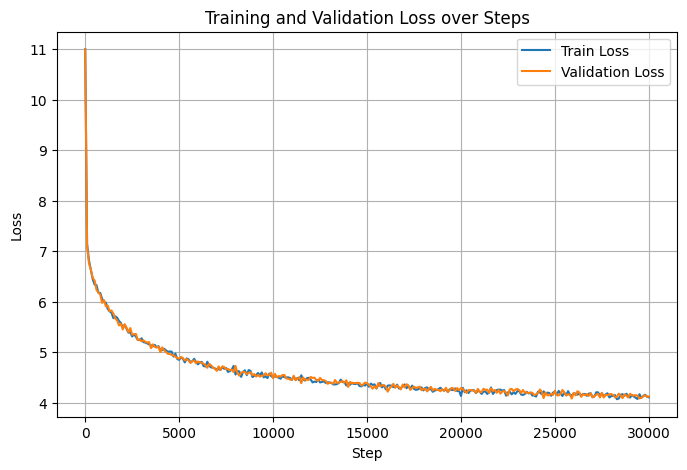

In [ ]:
# グラフ描画。
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(trainer.steps, trainer.train_losses, label='Train Loss')
plt.plot(trainer.steps, trainer.val_losses, label='Validation Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Steps')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 推論もやってみる
# 評価モードに切り替え。ドロップアウトを無効化する。
model.eval()
print("Model set to eval mode")

Model set to eval mode


In [ ]:
prompt = "New York is"
print(f"\n入力プロンプト: {prompt}")

encoder = tiktoken.get_encoding("gpt2")

# トークナイズしてテンソル化
encoded = encoder.encode(prompt, allowed_special="all") # テキストをIDにエンコード
print("encoded", encoded)
encoded_tensor = torch.tensor(encoded, dtype=torch.long) # IDのリストをテンソルの形式に変換する
print_formatted_tensor(encoded_tensor)
encoded_tensor = encoded_tensor.unsqueeze(0)  # バッチ次元追加
print_formatted_tensor(encoded_tensor)
encoded_tensor = encoded_tensor.to(config.device_type) # cuda(GPU)にencoded_tensorを転送する
print_formatted_tensor(encoded_tensor)


入力プロンプト: New York is
encoded [3791, 1971, 318]
Tensor Size: [3]
tensor([
         3791.00, 1971.00, 318.00
       ])
Tensor Size: [1, 3]
tensor([
         [3791.00, 1971.00, 318.00]
       ])
Tensor Size: [1, 3]
tensor([
         [3791.00, 1971.00, 318.00]
       ])


In [ ]:
# テキスト生成
generated_text = model.generate(encoded_tensor, max_new_tokens=512)

#### **学習後に一番重要なチェック場所**

出力を確認してみましょう。誤差はおよそ4.0~4.1だと思います。

比較的、文章のようになっているのが分かると思います。

文脈は飛躍や不自然さが残るものの、ある程度テーマの一貫性もあります。

tokenizerを変更する前の誤差は1.0~1.1でしたが、生成される文章の品質自体はむしろ体感として上がっています。

loss が大きいのは単純に分類が難しくなったからです。1文字ごとにトークン化していた時は、基本的に26文字のアルファベットから次のトークンを予測するだけでしたが、今はおよそ5万種類のサブワードから予測します。もちろん5万種類のうちほとんど使われないものもありますが、分類の難易度は当然上がります。この結果、lossはどうしても大きくなります。

---

計算資源を投入したことで、モデルの性能は着実に向上しました。

ただし図を見ると、すでに`loss plateau`の状態に近づきつつあり、これ以上の改善は限定的です。

モデルをさらに巨大にして`loss plateau`を下げる作戦もありますが、より計算資源を必要とするので、悩みどころですね。

このトレードオフが有名なスケーリング則につながっていきます。

In [ ]:
decoded_text = encoder.decode(generated_text[0].tolist())
print(decoded_text)

New York is responsible for marine waste cleanup services which shape the U.S. exposure scene.
"The shoreline shows a strong preference for drinking and harvesting data during the fish sanctuary to demonstrate their own ecosystem services. It was understained between 1983 and 2009, and 1969, with Shanghai Air Union as the largest shipping segment north of the US . It is the first comprehensive organization of the country". It is the branch of the U.S. Global Climate Agreement. The U.S. is the second leading full-blown ocean resource in the world. It is the only platform in the world where private companies carry the United States and the four major corporations in the U.S. bring energy and energy and traditional food energy to our entire region.
In addition toboth the North and South Asia and the Middle East, the environmental impacts of various marine toxins that contribute to the conservation of species. The Global Energy Initiative (NPLLI), while at rest, is a cooperative effort to 

今回もT4 GPUをたっぷり使って学習してるので、学習ログはきちんと保管しましょう。

おすすめはGoole Driveです。

In [ ]:
# 学習済み trainer からログをまとめる
results = {
    "step": trainer.steps,
    "train_loss": trainer.train_losses,
    "val_loss": trainer.val_losses,
    "total_seen_tokens": trainer.total_seen_tokens_list,
    "total_train_time": trainer.total_train_time_list,
}

print(results)

{'step': [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000, 5100, 5200, 5300, 5400, 5500, 5600, 5700, 5800, 5900, 6000, 6100, 6200, 6300, 6400, 6500, 6600, 6700, 6800, 6900, 7000, 7100, 7200, 7300, 7400, 7500, 7600, 7700, 7800, 7900, 8000, 8100, 8200, 8300, 8400, 8500, 8600, 8700, 8800, 8900, 9000, 9100, 9200, 9300, 9400, 9500, 9600, 9700, 9800, 9900, 10000, 10100, 10200, 10300, 10400, 10500, 10600, 10700, 10800, 10900, 11000, 11100, 11200, 11300, 11400, 11500, 11600, 11700, 11800, 11900, 12000, 12100, 12200, 12300, 12400, 12500, 12600, 12700, 12800, 12900, 13000, 13100, 13200, 13300, 13400, 13500, 13600, 13700, 13800, 13900, 14000, 14100, 14200, 14300, 14400, 14500, 14600, 14700, 14800, 14900, 15000, 15100, 15200, 15300, 15400, 15500, 15600, 157

In [ ]:
import pandas as pd
# pandas の DataFrame に変換
df = pd.DataFrame(results)

In [ ]:
df

,step,train_loss,val_loss,total_seen_tokens,total_train_time
0,0,10.999835,10.994602,0,0.000000
1,100,7.143936,7.086850,819200,76.111654
2,200,6.818138,6.758621,1638400,151.539542
3,300,6.633192,6.632315,2457600,226.542658
4,400,6.444882,6.467705,3276800,301.266527
...,...,...,...,...,...
296,29600,4.095649,4.096364,242483200,21925.562124
297,29700,4.130576,4.128162,243302400,21999.839039
298,29800,4.157111,4.147010,244121600,22073.889359
299,29900,4.121974,4.116218,244940800,22147.941723


In [ ]:
# 保存先のフォルダを作成する
import os
dir_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter19"
os.makedirs(dir_path, exist_ok=True)

In [ ]:
# csvファイルとして保存する先のパスを指定する。
save_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter19/training_logs.csv"

In [ ]:
# CSVとして保存
df.to_csv(save_path, index=False)
print(f"✅ CSV saved to: {save_path}")

✅ CSV saved to: /content/drive/MyDrive/nanoGPT_logs/Chapter19/training_logs.csv


In [ ]:
# クラス属性を辞書化
config_class_dict = vars(config.__class__)
print(config_class_dict)

{'__module__': '__main__', 'batch_size': 16, 'input_sequence_length': 512, 'total_training_steps': 30000, 'device_type': 'cuda', 'evaluation_frequency': 100, 'learning_rate': 0.001, 'evaluation_loops': 10, 'embedding_dim': 512, 'hidden_dim': 2048, 'num_attention_heads': 8, 'layer_count': 4, 'dropout_rate': 0.1, 'random_seed_value': 1337, '__dict__': <attribute '__dict__' of 'ModelConfig' objects>, '__weakref__': <attribute '__weakref__' of 'ModelConfig' objects>, '__doc__': None}


In [ ]:
# 辞書の (key, value) ペアを取得
config_dict_items = config_class_dict.items()
print(config_dict_items)

dict_items([('__module__', '__main__'), ('batch_size', 16), ('input_sequence_length', 512), ('total_training_steps', 30000), ('device_type', 'cuda'), ('evaluation_frequency', 100), ('learning_rate', 0.001), ('evaluation_loops', 10), ('embedding_dim', 512), ('hidden_dim', 2048), ('num_attention_heads', 8), ('layer_count', 4), ('dropout_rate', 0.1), ('random_seed_value', 1337), ('__dict__', <attribute '__dict__' of 'ModelConfig' objects>), ('__weakref__', <attribute '__weakref__' of 'ModelConfig' objects>), ('__doc__', None)])


In [ ]:
config_dict = {
    key: value
    for key, value in config_dict_items
    if not key.startswith("__")
}

print(config_dict)

{'batch_size': 16, 'input_sequence_length': 512, 'total_training_steps': 30000, 'device_type': 'cuda', 'evaluation_frequency': 100, 'learning_rate': 0.001, 'evaluation_loops': 10, 'embedding_dim': 512, 'hidden_dim': 2048, 'num_attention_heads': 8, 'layer_count': 4, 'dropout_rate': 0.1, 'random_seed_value': 1337}


In [ ]:
# 保存先のファイルパスを作成する。
# dir_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter17"
config_path = os.path.join(dir_path, "model_config.json")
print(config_path)

/content/drive/MyDrive/nanoGPT_logs/Chapter19/model_config.json


In [ ]:
import json
# ファイルを「書き込みモード(w)」で開き、変数`f`で操作できるようにする
with open(config_path, "w") as f:
    json.dump(config_dict, f)

print(f"✅ Config saved to: {config_path}")

✅ Config saved to: /content/drive/MyDrive/nanoGPT_logs/Chapter19/model_config.json


In [ ]:
model_path = os.path.join(dir_path, "model.pt")
print(model_path)

/content/drive/MyDrive/nanoGPT_logs/Chapter19/model.pt


In [ ]:
torch.save(model.state_dict(), model_path)
print(f"✅ Model saved to: {model_path}")

✅ Model saved to: /content/drive/MyDrive/nanoGPT_logs/Chapter19/model.pt


**Section 3: 長時間の学習** <label><input type="checkbox"> Mark as Done</label>

**⚠️ 右上の 🔽 からランタイムを接続解除してクレジット消費を止めてください。** <label><input type="checkbox">接続解除した</label>

**Chapter 19: Long Train** <label><input type="checkbox"> Mark as Done</label>